# Graph Interpretation Bottleneck on a Hidden Automaton

This notebook builds a controlled hidden-automaton benchmark for the graph interpretation bottleneck. It uses a sparse directed automaton with hidden states, generates observable symbol sequences, trains a tiny sequence transformer, trains the bottleneck graphicalizer on the resulting token embeddings, and visualizes the true graph next to the learned graph.

The learned graph is aggregated across the full dataset before visualization. This matters because prototypes are global, while each individual transformed sequence is only one local graph instance.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]
repo_root


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos/abstractgraph-graphicalizer')

In [2]:
import math
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch

from abstractgraph_graphicalizer.bottleneck import (
    BottleneckGraphicalizer,
    HiddenAutomaton,
    evaluate_automaton_recovery,
    extract_sequence_embeddings,
    generate_automaton_sequences,
    train_tiny_sequence_transformer,
)

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


## 1. Build a Sparse Hidden Automaton

The benchmark automaton is intentionally structured: each hidden state has a distinctive emission pair and two main outgoing transitions. The model only sees emitted symbol sequences; hidden states and transition probabilities are kept for evaluation and plotting.


In [3]:
transition_probs = np.array(
    [
        [0.05, 0.75, 0.20, 0.00],
        [0.00, 0.05, 0.80, 0.15],
        [0.20, 0.00, 0.05, 0.75],
        [0.85, 0.10, 0.00, 0.05],
    ],
    dtype=float,
)

emission_probs = np.eye(transition_probs.shape[0], dtype=float)

start_probs = np.full(transition_probs.shape[0], 1.0 / transition_probs.shape[0])
automaton = HiddenAutomaton(
    transition_probs=transition_probs,
    emission_probs=emission_probs,
    start_probs=start_probs,
    symbols=tuple(range(emission_probs.shape[1])),
)

data = generate_automaton_sequences(
    automaton,
    n_sequences=180,
    length=48,
    random_state=SEED + 1,
)

print("states:", automaton.n_states)
print("vocab size:", automaton.vocab_size)
print("sequences:", len(data["sequences"]))
print("first observed sequence:", data["sequences"][0].tolist())
print("first hidden path:", data["hidden_states"][0].tolist())


states: 4
vocab size: 4
sequences: 180
first observed sequence: [1, 2, 3, 0, 1, 2, 0, 2, 3, 0, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 3, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 0, 1, 2, 3, 0, 2, 3, 0, 2, 3, 1]
first hidden path: [1, 2, 3, 0, 1, 2, 0, 2, 3, 0, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 3, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 0, 1, 2, 3, 0, 2, 3, 0, 2, 3, 1]


In [4]:
TRUE_EDGE_THRESHOLD = 0.099

def transition_graph_from_automaton(automaton, threshold=TRUE_EDGE_THRESHOLD):
    graph = nx.DiGraph()
    for state in range(automaton.n_states):
        graph.add_node(state, label=f"s{state}")
    for src in range(automaton.n_states):
        for dst in range(automaton.n_states):
            prob = float(automaton.transition_probs[src, dst])
            if prob >= threshold:
                graph.add_edge(src, dst, probability=prob, weight=prob)
    return graph

true_graph = transition_graph_from_automaton(automaton)
true_graph.number_of_nodes(), true_graph.number_of_edges()


(4, 8)

## 2. Build Observable Token Embeddings

For this visualization notebook, the default path uses one-hot embeddings of the observed symbols. This isolates the graphicalizer/graph-recovery behavior from the quality of a separately trained sequence encoder. The tiny transformer utilities are still available for harder follow-up experiments, but the one-hot path gives a stable sanity check with clear figures.


In [5]:
symbol_eye = np.eye(automaton.vocab_size, dtype=np.float32)
embeddings = [symbol_eye[sequence] for sequence in data["sequences"]]
print(len(embeddings), embeddings[0].shape)


180 (48, 4)


## 3. Train the Bottleneck Graphicalizer

The graphicalizer receives only the transformer embeddings. The hidden state labels are not passed to training.


In [6]:
graphicalizer = BottleneckGraphicalizer(
    d_model=automaton.vocab_size,
    num_prototypes=12,
    use_encoder=False,
    n_epochs=12,
    lr=2e-3,
    output_graph="directed",
    active_only=True,
    top_k_edges=2,
    edge_threshold=0.30,
    gnn_layers=1,
    hidden_dim=16,
    temperature=0.05,
    node_mask_ratio=0.2,
    token_mask_ratio=0.2,
    lambda_token=0.2,
    lambda_sparse=0.03,
    lambda_binary=0.01,
    lambda_entropy=0.05,
    lambda_transition=0.10,
    lambda_balance=0.03,
    device="cpu",
)

learned_graphs = graphicalizer.fit_transform(embeddings)
print("learned graphs:", len(learned_graphs))
print("first learned graph nodes/edges:", learned_graphs[0].number_of_nodes(), learned_graphs[0].number_of_edges())


learned graphs: 180
first learned graph nodes/edges: 8 16


## 4. Quantitative Diagnostics

These metrics use the hidden state trace only after training. They are useful for comparing runs and hyperparameters, but the visual graph comparison below is often more informative.


In [7]:
def aggregate_predictive_graph(graphs, *, min_edge_frequency=0.10, top_k_per_source=2):
    n_graphs = max(1, len(graphs))
    node_mass = defaultdict(float)
    node_seen = Counter()
    edge_score = defaultdict(float)
    edge_seen = Counter()

    for graph in graphs:
        for _, attrs in graph.nodes(data=True):
            proto = int(attrs["prototype_id"])
            node_mass[proto] += float(attrs.get("assignment_mass", 0.0))
            node_seen[proto] += 1
        for u, v, attrs in graph.edges(data=True):
            src = int(graph.nodes[u]["prototype_id"])
            dst = int(graph.nodes[v]["prototype_id"])
            edge_score[(src, dst)] += float(attrs.get("probability", attrs.get("weight", 0.0)))
            edge_seen[(src, dst)] += 1

    out = nx.DiGraph()
    for proto in sorted(node_mass):
        out.add_node(proto, prototype_id=proto, assignment_mass=node_mass[proto] / node_seen[proto], label=proto)

    outgoing = defaultdict(list)
    for (src, dst), total in edge_score.items():
        frequency = edge_seen[(src, dst)] / n_graphs
        if frequency < min_edge_frequency:
            continue
        probability = total / edge_seen[(src, dst)]
        outgoing[src].append((probability * frequency, dst, probability, frequency))

    for src, candidates in outgoing.items():
        for _, dst, probability, frequency in sorted(candidates, reverse=True)[:top_k_per_source]:
            out.add_edge(src, dst, probability=float(probability), frequency=float(frequency), weight=float(probability * frequency))
    return out


def learned_transition_graph_from_assignments(graphs, *, top_k_per_source=2, min_count=8):
    node_ids = set()
    edge_counts = Counter()
    outgoing_counts = Counter()
    for graph in graphs:
        sequence_nodes = [int(node) for node in graph.graph["token_to_nodes"]]
        node_ids.update(sequence_nodes)
        for src, dst in zip(sequence_nodes[:-1], sequence_nodes[1:]):
            edge_counts[(src, dst)] += 1
            outgoing_counts[src] += 1

    out = nx.DiGraph()
    for proto in sorted(node_ids):
        out.add_node(proto, prototype_id=proto, label=proto)

    outgoing = defaultdict(list)
    for (src, dst), count in edge_counts.items():
        if count < min_count:
            continue
        probability = count / max(1, outgoing_counts[src])
        outgoing[src].append((probability, dst, count))

    for src, candidates in outgoing.items():
        for probability, dst, count in sorted(candidates, reverse=True)[:top_k_per_source]:
            out.add_edge(src, dst, probability=float(probability), frequency=float(count / len(graphs)), weight=float(probability))
    return out

aggregate_predictive_graph = aggregate_predictive_graph(
    learned_graphs,
    min_edge_frequency=0.12,
    top_k_per_source=2,
)
learned_transition_graph = learned_transition_graph_from_assignments(
    learned_graphs,
    top_k_per_source=2,
    min_count=8,
)
learned_assignments = [graph.graph["token_to_nodes"] for graph in learned_graphs]
metrics = evaluate_automaton_recovery(
    learned_assignments,
    data["hidden_states"],
    learned_graph=learned_transition_graph,
    automaton=automaton,
    transition_threshold=TRUE_EDGE_THRESHOLD,
)
print("aggregate predictive graph nodes/edges:", aggregate_predictive_graph.number_of_nodes(), aggregate_predictive_graph.number_of_edges())
print("learned transition graph nodes/edges:", learned_transition_graph.number_of_nodes(), learned_transition_graph.number_of_edges())
metrics


aggregate predictive graph nodes/edges: 9 16
learned transition graph nodes/edges: 4 8


{'clustering_accuracy': 1.0,
 'purity': 1.0,
 'ari': 1.0,
 'nmi': 1.0,
 'n_learned_nodes': 4.0,
 'n_true_states': 4.0,
 'mean_prototype_state_entropy': 0.0,
 'max_prototypes_per_state': 1.0,
 'edge_precision': 1.0,
 'edge_recall': 1.0,
 'edge_auroc': 1.0,
 'edge_symmetric_difference': 0.0,
 'vf2_isomorphic_unlabelled': True}

In [8]:
def prototype_state_counts(graphs, hidden_states):
    counts = defaultdict(Counter)
    for graph, states in zip(graphs, hidden_states):
        token_to_nodes = graph.graph["token_to_nodes"]
        for token_idx, proto in enumerate(token_to_nodes):
            counts[proto][int(states[token_idx])] += 1
    return counts

def majority_state_map(counts):
    mapping = {}
    for proto, counter in counts.items():
        if counter:
            mapping[int(proto)] = int(counter.most_common(1)[0][0])
    return mapping

proto_counts = prototype_state_counts(learned_graphs, data["hidden_states"])
proto_to_state = majority_state_map(proto_counts)
proto_to_state


{3: 1, 4: 2, 8: 3, 9: 0}

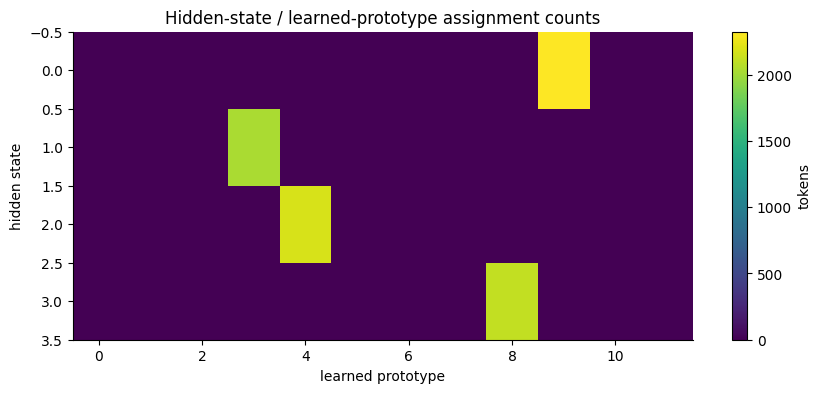

In [9]:
confusion = np.zeros((automaton.n_states, graphicalizer.num_prototypes), dtype=int)
for graph, states in zip(learned_graphs, data["hidden_states"]):
    for proto, state in zip(graph.graph["token_to_nodes"], states):
        confusion[int(state), int(proto)] += 1

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(confusion, aspect="auto", cmap="viridis")
ax.set_title("Hidden-state / learned-prototype assignment counts")
ax.set_xlabel("learned prototype")
ax.set_ylabel("hidden state")
fig.colorbar(im, ax=ax, label="tokens")
plt.show()


## 5. Visualize True and Learned Graphs

The left plot is the hidden automaton. The right plot is the learned transition graph induced by bottleneck prototype assignments along observed token trajectories. Nodes are prototypes, colored by their majority hidden state after training. This is the cleanest visual comparison for the finite-state automaton experiment.


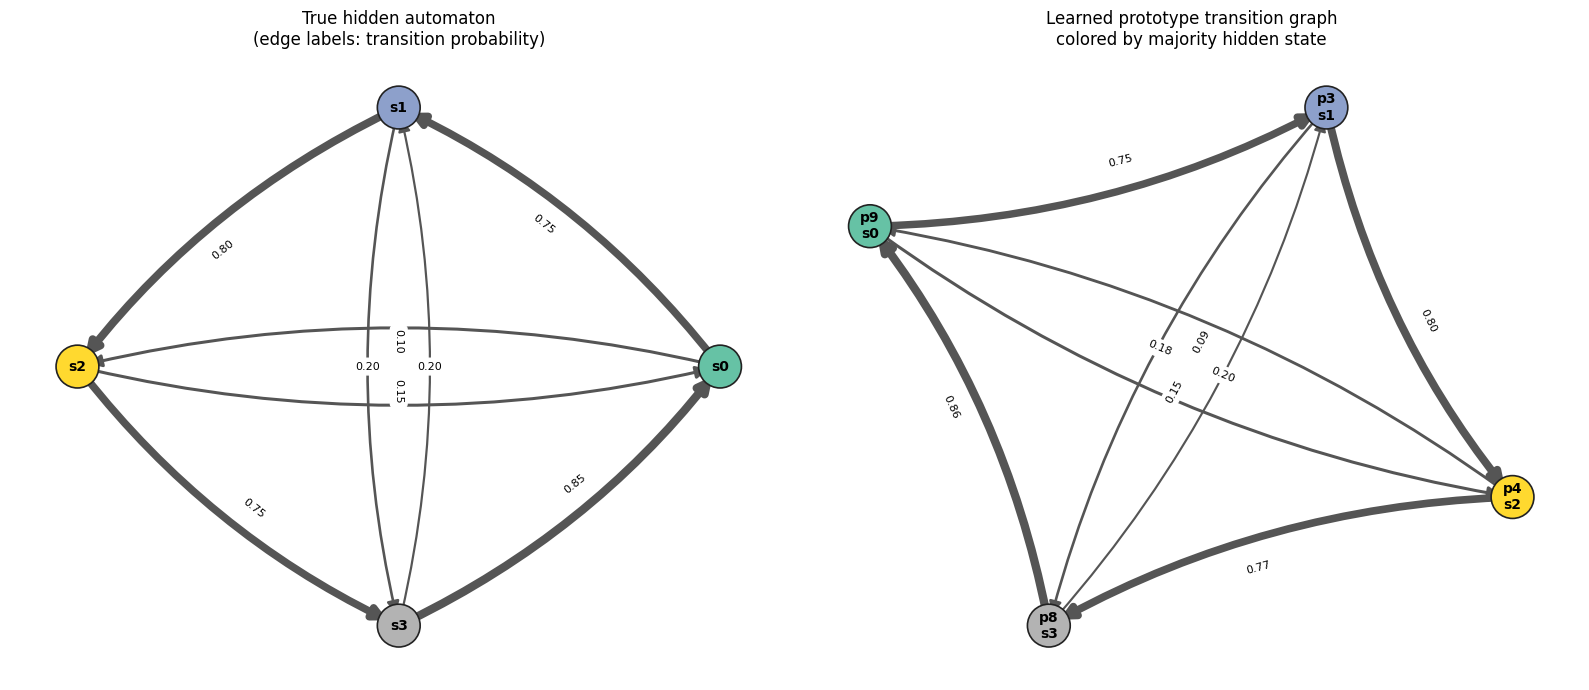

In [10]:
state_palette = plt.cm.Set2(np.linspace(0, 1, automaton.n_states))
state_colors = {state: state_palette[state] for state in range(automaton.n_states)}


def draw_weighted_digraph(ax, graph, pos, title, node_state=None, node_labels=None, edge_key="probability", edge_label_key="probability"):
    node_colors = []
    for node in graph.nodes():
        state = node_state[node] if node_state is not None and node in node_state else node
        node_colors.append(state_colors.get(int(state), (0.75, 0.75, 0.75, 1.0)))

    edge_values = [float(graph.edges[e].get(edge_key, graph.edges[e].get("weight", 0.1))) for e in graph.edges()]
    max_edge = max(edge_values) if edge_values else 1.0
    widths = [1.0 + 5.0 * (value / max_edge) for value in edge_values]
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=950, edgecolors="#222222", linewidths=1.2, ax=ax)
    nx.draw_networkx_edges(
        graph,
        pos,
        width=widths,
        edge_color="#555555",
        arrows=True,
        arrowsize=18,
        connectionstyle="arc3,rad=0.12",
        ax=ax,
    )
    labels = node_labels or {node: str(node) for node in graph.nodes()}
    nx.draw_networkx_labels(graph, pos, labels=labels, font_size=10, font_weight="bold", ax=ax)
    edge_labels = {
        edge: f"{float(graph.edges[edge].get(edge_label_key, graph.edges[edge].get('weight', 0.0))):.2f}"
        for edge in graph.edges()
    }
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8, ax=ax, label_pos=0.55)
    ax.set_title(title)
    ax.set_axis_off()

true_pos = nx.circular_layout(true_graph)

learned_proto_state = {}
learned_labels = {}
for node, attrs in learned_transition_graph.nodes(data=True):
    proto = int(attrs["prototype_id"])
    learned_proto_state[node] = proto_to_state.get(proto, -1)
    learned_labels[node] = f"p{proto}\ns{learned_proto_state[node]}"

learned_pos = nx.spring_layout(learned_transition_graph, seed=SEED, k=1.1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
draw_weighted_digraph(
    axes[0],
    true_graph,
    true_pos,
    "True hidden automaton\n(edge labels: transition probability)",
    node_state={node: node for node in true_graph.nodes()},
    node_labels={node: f"s{node}" for node in true_graph.nodes()},
    edge_key="probability",
    edge_label_key="probability",
)
draw_weighted_digraph(
    axes[1],
    learned_transition_graph,
    learned_pos,
    "Learned prototype transition graph\ncolored by majority hidden state",
    node_state=learned_proto_state,
    node_labels=learned_labels,
    edge_key="probability",
    edge_label_key="probability",
)
plt.tight_layout()
plt.show()


## 6. Collapse Learned Prototypes Back to Inferred States

This view aggregates learned prototype edges by the majority hidden state assigned to each prototype. It uses labels only for post-hoc inspection and should be visually comparable to the true automaton.


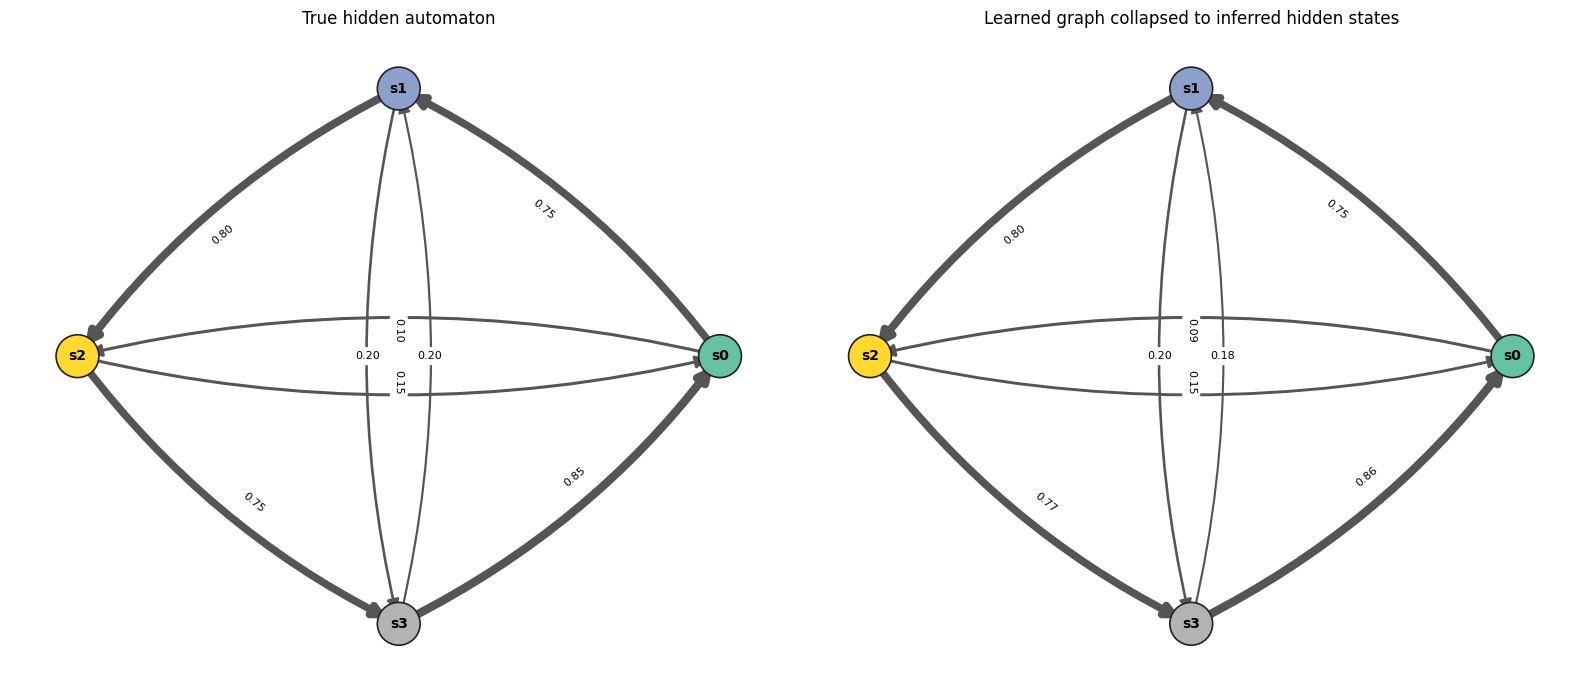

In [11]:
def collapse_learned_graph_to_states(graph, proto_to_state, n_states, *, top_k_per_source=2):
    collapsed = nx.DiGraph()
    for state in range(n_states):
        collapsed.add_node(state, label=f"s{state}")

    edge_weights = defaultdict(float)
    edge_counts = defaultdict(int)
    for u, v, attrs in graph.edges(data=True):
        src_proto = int(graph.nodes[u]["prototype_id"])
        dst_proto = int(graph.nodes[v]["prototype_id"])
        if src_proto not in proto_to_state or dst_proto not in proto_to_state:
            continue
        src_state = proto_to_state[src_proto]
        dst_state = proto_to_state[dst_proto]
        score = float(attrs.get("weight", attrs.get("probability", 0.0)))
        edge_weights[(src_state, dst_state)] += score
        edge_counts[(src_state, dst_state)] += 1

    outgoing = defaultdict(list)
    for edge, total in edge_weights.items():
        score = total / edge_counts[edge]
        outgoing[edge[0]].append((score, edge[1]))

    for src, candidates in outgoing.items():
        for score, dst in sorted(candidates, reverse=True)[:top_k_per_source]:
            collapsed.add_edge(src, dst, probability=float(score), weight=float(score))
    return collapsed

collapsed_graph = collapse_learned_graph_to_states(learned_transition_graph, proto_to_state, automaton.n_states)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
draw_weighted_digraph(
    axes[0],
    true_graph,
    true_pos,
    "True hidden automaton",
    node_state={node: node for node in true_graph.nodes()},
    node_labels={node: f"s{node}" for node in true_graph.nodes()},
)
draw_weighted_digraph(
    axes[1],
    collapsed_graph,
    true_pos,
    "Learned graph collapsed to inferred hidden states",
    node_state={node: node for node in collapsed_graph.nodes()},
    node_labels={node: f"s{node}" for node in collapsed_graph.nodes()},
)
plt.tight_layout()
plt.show()


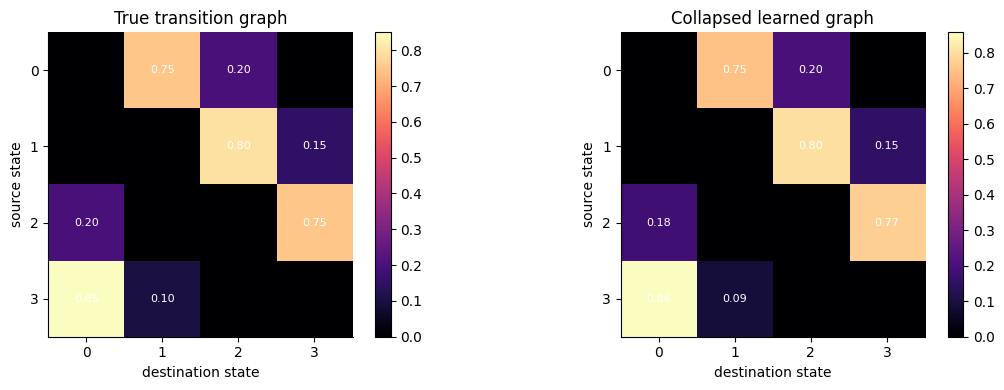

In [12]:
true_adj = nx.to_numpy_array(true_graph, nodelist=list(range(automaton.n_states)), weight="probability")
learned_adj = nx.to_numpy_array(collapsed_graph, nodelist=list(range(automaton.n_states)), weight="probability")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mat, title in zip(axes, [true_adj, learned_adj], ["True transition graph", "Collapsed learned graph"]):
    im = ax.imshow(mat, cmap="magma", vmin=0.0)
    ax.set_title(title)
    ax.set_xlabel("destination state")
    ax.set_ylabel("source state")
    ax.set_xticks(range(automaton.n_states))
    ax.set_yticks(range(automaton.n_states))
    for row in range(mat.shape[0]):
        for col in range(mat.shape[1]):
            if mat[row, col] > 0:
                ax.text(col, row, f"{mat[row, col]:.2f}", ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 7. Try Another Run

Useful knobs for visual recovery experiments:

- increase `n_sequences` and sequence `length`,
- train the tiny transformer for more epochs,
- train `BottleneckGraphicalizer` for more epochs,
- set `num_prototypes` near a small multiple of the hidden state count,
- reduce `transition_concentration` to make the true automaton sparser.
